# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [128]:
train = pd.read_csv('messi_all_goals.csv')
# Membuat target kategorikal 'Target_Home' dari is_home_goal
train['Target_Home'] = train['is_home_goal'].astype(int)
train.head()

,competition,match_stage,date,venue,club,opponent,match_score,player_position,goal_minute,score_at_goal,goal_type,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket,Target_Home
0,2ª B - Grupo III,2,2004-09-05,Home,FC Barcelona B,Girona FC,1:2,LW,65,1:2,Left-footed shot,Dani Fernández,2004-05,2000s,True,61-75,1
1,2ª B - Grupo III,4,2004-09-18,Home,FC Barcelona B,RCD Espanyol B,2:0,LW,88,2:0,Left-footed shot,Dani Fernández,2004-05,2000s,True,76-90,1
2,2ª B - Grupo III,10,2004-10-31,Away,FC Barcelona B,Villajoyosa CF,2:1,AM,2,0:1,Not reported,Not Applicable,2004-05,2000s,False,0-15,0
3,2ª B - Grupo III,14,2004-11-28,Away,FC Barcelona B,UE Figueres,2:2,AM,20,0:1,Not reported,Not Applicable,2004-05,2000s,False,16-30,0
4,2ª B - Grupo III,17,2004-12-19,Home,FC Barcelona B,CD Alcoyano,2:0,CF,40,2:0,Left-footed shot,Not Applicable,2004-05,2000s,True,31-45,1


### Exploratory Data Analysis

In [129]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   competition         790 non-null    object
 1   match_stage         790 non-null    object
 2   date                790 non-null    object
 3   venue               790 non-null    object
 4   club                790 non-null    object
 5   opponent            790 non-null    object
 6   match_score         790 non-null    object
 7   player_position     790 non-null    object
 8   goal_minute         790 non-null    int64 
 9   score_at_goal       790 non-null    object
 10  goal_type           790 non-null    object
 11  assist_player       790 non-null    object
 12  season              790 non-null    object
 13  goal_decade         790 non-null    object
 14  is_home_goal        790 non-null    bool  
 15  goal_minute_bucket  790 non-null    object
 16  Target_Home         790 no

In [130]:
d = train.describe()
d

,goal_minute,Target_Home
count,790.000000,790.000000
mean,51.981013,0.594937
std,26.045313,0.491215
min,2.000000,0.000000
25%,29.000000,0.000000
50%,54.000000,1.000000
75%,75.000000,1.000000
max,110.000000,1.000000


/tmp/ipykernel_1534/3761122474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target_Home',data=train,palette='RdBu_r')


<Axes: xlabel='Target_Home', ylabel='count'>

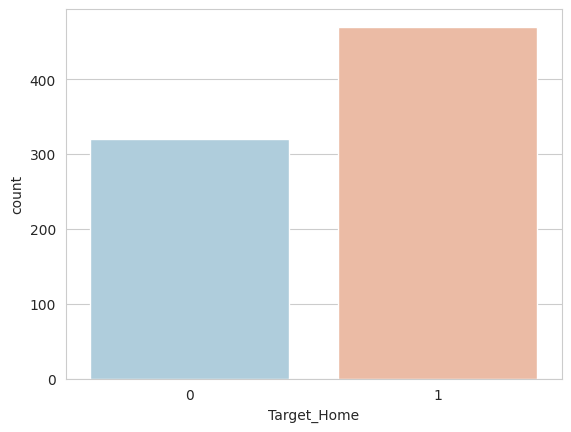

In [131]:
# Cek relative size dari kelas target
sns.set_style('whitegrid')
sns.countplot(x='Target_Home',data=train,palette='RdBu_r')

<Axes: title={'center': 'Histogram Goal Minute'}, xlabel='Goal Minute', ylabel='Count'>

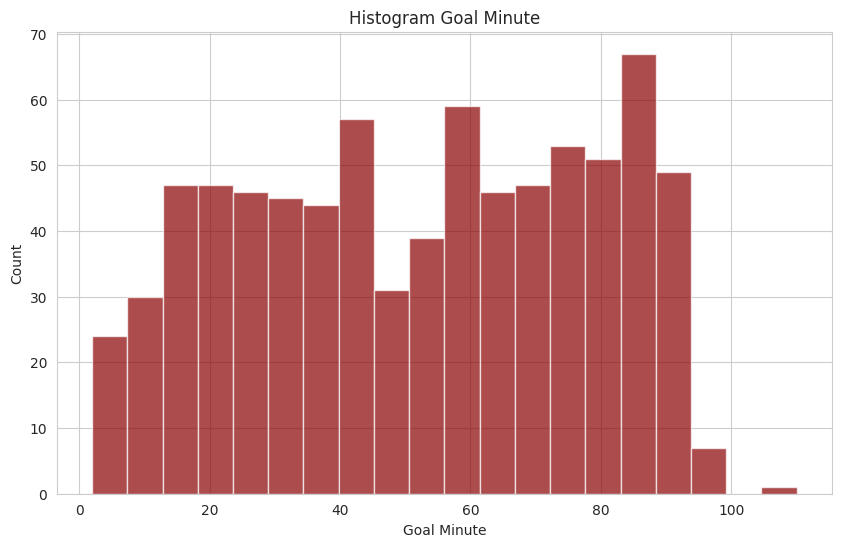

In [132]:
# Histogram Goal Minute
plt.xlabel('Goal Minute')
plt.ylabel('Count')
plt.title('Histogram Goal Minute')
train['goal_minute'].hist(bins=20, color='darkred', alpha=0.7, figsize=(10,6))

In [133]:
numerical_features = train.select_dtypes(include=['int64', 'float64'])
display(numerical_features.head())

,goal_minute,Target_Home
0,65,1
1,88,1
2,2,0
3,20,0
4,40,1


In [135]:
correlation_with_target = train.corr(numeric_only=True)['Target_Home'].sort_values(ascending=False)

# Exclude Target_Home itself from the correlation list
correlation_with_target = correlation_with_target.drop('Target_Home')

# Display top 10 positive and top 10 negative correlations
display(correlation_with_target.head(10))
display(correlation_with_target.tail(10))

,Target_Home
is_home_goal,1.000000
goal_minute,-0.055088


,Target_Home
is_home_goal,1.000000
goal_minute,-0.055088


In [ ]:
# Visualisasikan 15 fitur teratas dengan korelasi terkuat (baik positif maupun negatif)
plt.figure(figsize=(12, 8))

# Gabungkan korelasi positif teratas dan korelasi negatif teratas
top_correlated_features = pd.concat([correlation_with_target.head(15), correlation_with_target.tail(15)])

sns.barplot(x=top_correlated_features.values, y=top_correlated_features.index, palette='coolwarm', hue=top_correlated_features.index, legend=False)
plt.title('Top 15 Features by Correlation with Target_Home')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

### Fitur Engineering

In [ ]:
# Drop kolom yang tidak diperlukan untuk klasifikasi dan lakukan encoding
train.drop(['date', 'match_score', 'score_at_goal', 'is_home_goal', 'venue'], axis=1, inplace=True)
train = pd.get_dummies(train, drop_first=True, dtype=int)
train.head()

### Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Target_Home',axis=1),
                                                    train['Target_Home'], test_size=0.30,
                                                    random_state=42)

In [ ]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

In [ ]:
y_pred = clf1.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print('Confusion Matrix:') #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print('Classification Report:') #laporan klasifikasi
print(classification_report(y_test, y_pred))

# Memperbarui prediksi untuk menggunakan best_model
y_pred = best_model.predict(X_test)

accuracy_best_knn = accuracy_score(y_test, y_pred)
print(f'\nAkurasi Model KNN (Best Model from GridSearchCV): {accuracy_best_knn:.2f}')

print('Confusion Matrix (Best Model from GridSearchCV):')
print(confusion_matrix(y_test, y_pred))

print('Classification Report (Best Model from GridSearchCV):')
print(classification_report(y_test, y_pred))

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi Label')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix KNN Model')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Lakukan PCA untuk mengurangi dimensi menjadi 2
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Prediksi menggunakan model KNN terbaik (best_model dari GridSearchCV)
y_pred_best_model = best_model.predict(X_test)

# Buat DataFrame untuk visualisasi
df_viz = pd.DataFrame(data=X_test_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_viz['Actual'] = y_test.values
df_viz['Predicted'] = y_pred_best_model
df_viz['Misclassified'] = (df_viz['Actual'] != df_viz['Predicted']).astype(int)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Actual',
    style='Misclassified',
    data=df_viz,
    palette='viridis',
    markers={0: 'o', 1: 'X'}, # Lingkaran untuk diklasifikasikan dengan benar, X untuk salah klasifikasi
    s=100, # Ukuran marker
    alpha=0.7
)
plt.title('KNN Classification Visualization (PCA Reduced Dimensions)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Kelas')
plt.grid(True)
plt.show()

# --- Tabel Informasi dan Hasil ---
# Dapatkan metrik evaluasi dari model KNN terbaik
accuracy_knn = accuracy_score(y_test, y_pred_best_model)
precision_knn = precision_score(y_test, y_pred_best_model, average='macro', zero_division=0)
recall_knn = recall_score(y_test, y_pred_best_model, average='macro', zero_division=0)
f1_knn = f1_score(y_test, y_pred_best_model, average='macro', zero_division=0)

# Buat DataFrame untuk laporan
report_data = {
    'Metric': ['Accuracy', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-Score (Macro Avg)'],
    'Value': [accuracy_knn, precision_knn, recall_knn, f1_knn]
}
df_report = pd.DataFrame(report_data)

print('\n### Ringkasan Evaluasi Model KNN (dengan GridSearchCV)')
print(df_report.to_markdown(index=False))

print('\n### Confusion Matrix')
print(confusion_matrix(y_test, y_pred_best_model))

print('\n### Classification Report')
print(classification_report(y_test, y_pred_best_model, zero_division=0))

# **Naive Bayes**

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_nb))

print('Classification Report:')
print(classification_report(y_test, y_pred_nb))

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi Label')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix Naive Bayes Model')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Lakukan PCA untuk mengurangi dimensi menjadi 2
pca_nb = PCA(n_components=2)
X_test_pca_nb = pca_nb.fit_transform(X_test)

# Prediksi menggunakan model Naive Bayes
y_pred_nb = nb.predict(X_test)

# Buat DataFrame untuk visualisasi
df_viz_nb = pd.DataFrame(data=X_test_pca_nb, columns=['Principal Component 1', 'Principal Component 2'])
df_viz_nb['Actual'] = y_test.values
df_viz_nb['Predicted'] = y_pred_nb
df_viz_nb['Misclassified'] = (df_viz_nb['Actual'] != df_viz_nb['Predicted']).astype(int)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Actual',
    style='Misclassified',
    data=df_viz_nb,
    palette='viridis',
    markers={0: 'o', 1: 'X'}, # Lingkaran untuk diklasifikasikan dengan benar, X untuk salah klasifikasi
    s=100, # Ukuran marker
    alpha=0.7
)
plt.title('Naive Bayes Classification Visualization (PCA Reduced Dimensions)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Kelas')
plt.grid(True)
plt.show()

# --- Tabel Informasi dan Hasil ---
# Dapatkan metrik evaluasi dari model Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='macro', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='macro', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='macro', zero_division=0)

# Buat DataFrame untuk laporan
report_data_nb = {
    'Metric': ['Accuracy', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-Score (Macro Avg)'],
    'Value': [accuracy_nb, precision_nb, recall_nb, f1_nb]
}
df_report_nb = pd.DataFrame(report_data_nb)

print('\n### Ringkasan Evaluasi Model Naive Bayes')
print(df_report_nb.to_markdown(index=False))

print('\n### Confusion Matrix')
print(confusion_matrix(y_test, y_pred_nb))

print('\n### Classification Report')
print(classification_report(y_test, y_pred_nb, zero_division=0))

# **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dt))

print('Classification Report:')
print(classification_report(y_test, y_pred_dt))

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi Label')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix Decision Tree Model')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Memperbaiki nama variabel model (dt) dan fitur (X_train)
plt.figure(figsize=(20,10))
plot_tree(dt,
          feature_names=X_train.columns,
          class_names=['Tandang (No)', 'Kandang (Yes)'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3) # Dibatasi agar tidak berdempetan
plt.title('Struktur Keputusan (Decision Tree)', fontsize=15)
plt.show()

### **Visualisasi Pohon Keputusan (Rapi untuk Presentasi)**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Mengatur ukuran gambar dan resolusi (DPI)
fig, ax = plt.subplots(figsize=(24, 12), dpi=100)

# Membuat plot pohon
plot_tree(dt,
          feature_names=X_train.columns,
          class_names=['Tandang (No)', 'Kandang (Yes)'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3,
          precision=2,
          proportion=False,
          impurity=False,
          ax=ax)

# Menambahkan kotak informasi/legenda dengan teks standar (menghindari error emoji font)
info_text = (
    "KETERANGAN WARNA:\n"
    "[BIRU]  : Dominan Kandang (Home)\n"
    "[ORANYE]: Dominan Tandang (Away)\n"
    "[PUTIH] : Data Campuran (50-50)\n"
    "---------------------------------------\n"
    "Kepekatan warna menunjukkan\n"
    "tingkat kemurnian prediksi."
)

plt.text(0.01, 0.98, info_text,
         transform=ax.transAxes,
         fontsize=12,
         family='monospace', # Font monospaced agar teks rapi sejajar
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=1', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.title("Struktur Prediksi Lokasi Pertandingan - Decision Tree", fontsize=20, pad=30)
plt.tight_layout()
plt.show()

# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Prediksi data uji
y_pred_rf = rf.predict(X_test)

### Evaluation

In [139]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Akurasi Model Random Forest: {accuracy_rf:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

Akurasi Model Random Forest: 0.61
Confusion Matrix:
[[ 31  65]
 [ 27 114]]
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.32      0.40        96
           1       0.64      0.81      0.71       141

    accuracy                           0.61       237
   macro avg       0.59      0.57      0.56       237
weighted avg       0.60      0.61      0.59       237



### Feature Importance Random Forest

Di bagian ini, kita akan melihat fitur mana saja yang paling berpengaruh dalam menentukan apakah gol dicetak di kandang atau tandang berdasarkan model Random Forest.

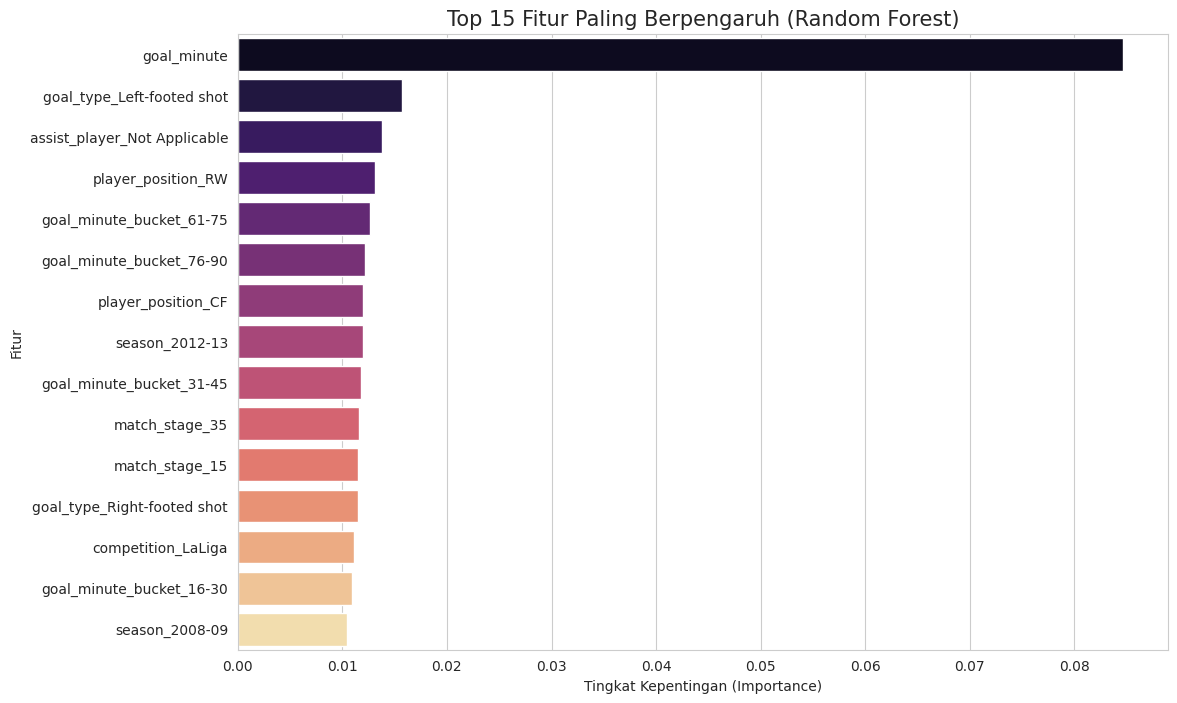

,Feature,Importance
0,goal_minute,0.084694
192,goal_type_Left-footed shot,0.015708
256,assist_player_Not Applicable,0.013745
186,player_position_RW,0.013145
312,goal_minute_bucket_61-75,0.012626
313,goal_minute_bucket_76-90,0.012158
184,player_position_CF,0.012019
293,season_2012-13,0.011936
310,goal_minute_bucket_31-45,0.011747
40,match_stage_35,0.011623


In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mendapatkan feature importance dari model Random Forest
importances = rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Mengurutkan berdasarkan tingkat kepentingan
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi 15 fitur teratas
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma', hue='Feature', legend=False)
plt.title('Top 15 Fitur Paling Berpengaruh (Random Forest)', fontsize=15)
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Fitur')
plt.show()

# Menampilkan tabel 10 fitur teratas
display(feature_importance_df.head(10))

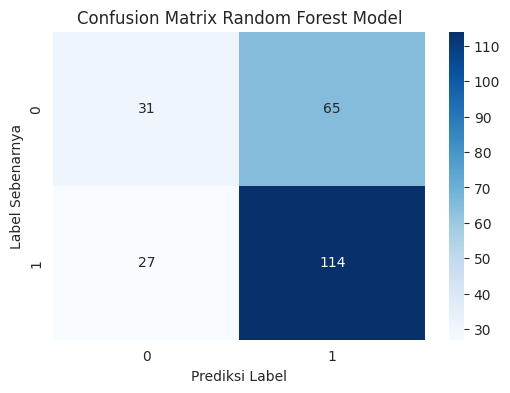

In [140]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi Label')
plt.ylabel('Label Sebenarnya')
plt.title('Confusion Matrix Random Forest Model')
plt.show()

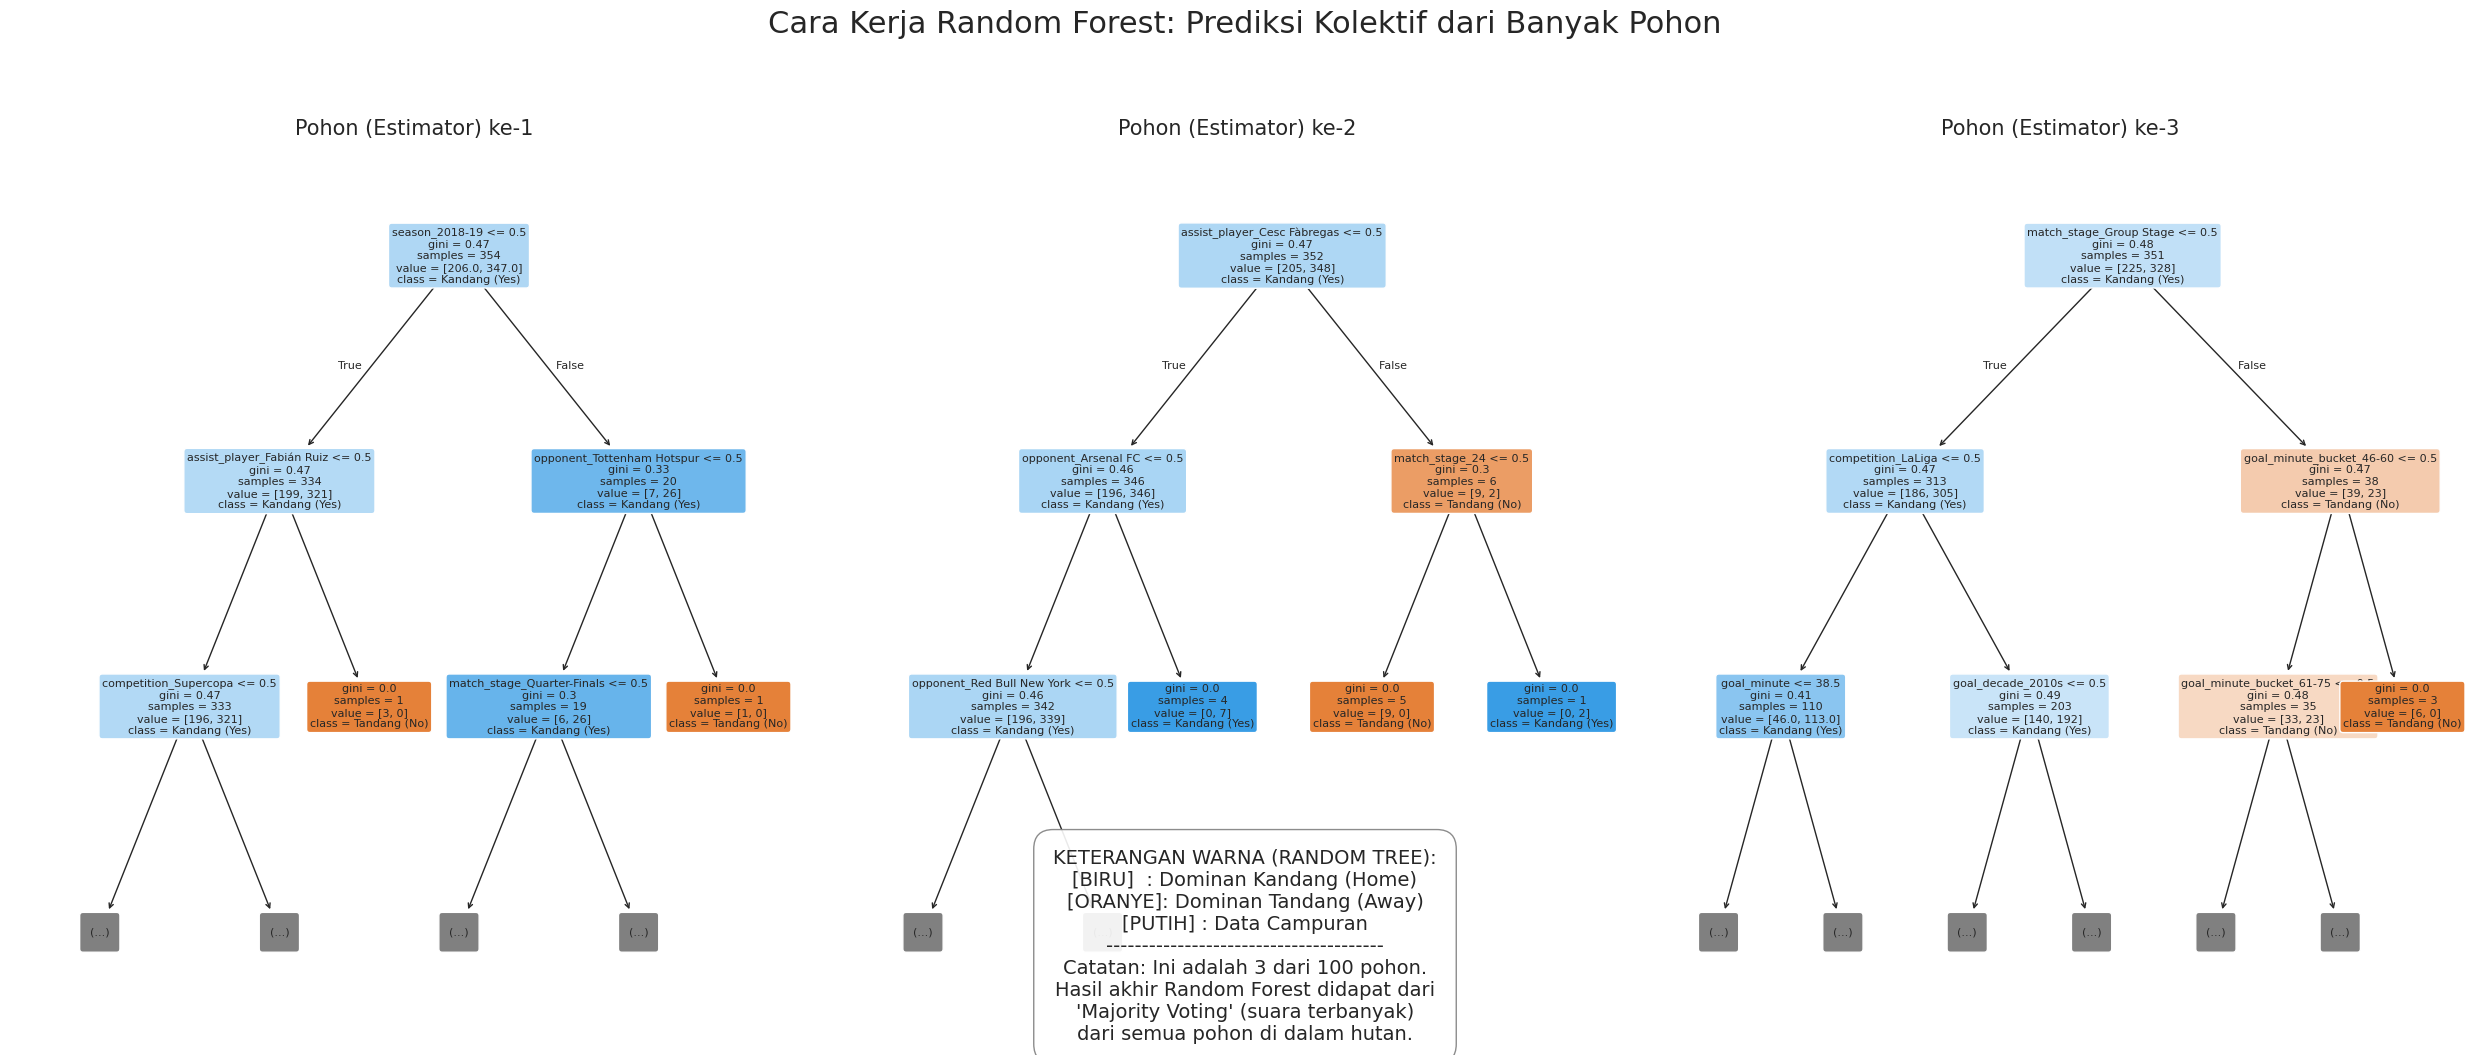

In [141]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Kita tampilkan 3 pohon berbeda untuk menunjukkan variasi di dalam Forest
n_trees_to_show = 3
fig, axes = plt.subplots(1, n_trees_to_show, figsize=(25, 10), dpi=100)

for i in range(n_trees_to_show):
    plot_tree(rf.estimators_[i],
              feature_names=X_train.columns,
              class_names=['Tandang (No)', 'Kandang (Yes)'],
              filled=True,
              rounded=True,
              fontsize=8,
              max_depth=2,
              precision=2,
              ax=axes[i])
    axes[i].set_title(f'Pohon (Estimator) ke-{i+1}', fontsize=15)

# Menambahkan keterangan konsep Voting
info_text = (
    "KETERANGAN WARNA (RANDOM TREE):\n"
    "[BIRU]  : Dominan Kandang (Home)\n"
    "[ORANYE]: Dominan Tandang (Away)\n"
    "[PUTIH] : Data Campuran\n"
    "---------------------------------------\n"
    "Catatan: Ini adalah 3 dari 100 pohon.\n"
    "Hasil akhir Random Forest didapat dari\n"
    "'Majority Voting' (suara terbanyak)\n"
    "dari semua pohon di dalam hutan."
)

fig.text(0.5, 0.02, info_text, ha='center', fontsize=14,
         bbox=dict(boxstyle='round,pad=1', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.suptitle("Cara Kerja Random Forest: Prediksi Kolektif dari Banyak Pohon", fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [143]:
from sklearn.naive_bayes import GaussianNB

# var_smoothing: Menambahkan porsi varians terbesar ke semua fitur untuk stabilitas perhitungan
# Nilai default adalah 1e-9
clf_nb_custom = GaussianNB(var_smoothing=1e-09)

# Melatih model
clf_nb_custom.fit(X_train, y_train)

print('Model Naive Bayes berhasil dilatih dengan var_smoothing=1e-09')

Model Naive Bayes berhasil dilatih dengan var_smoothing=1e-09


In [144]:
from sklearn.tree import DecisionTreeClassifier

# criterion: 'gini' atau 'entropy'
# max_depth: membatasi kedalaman agar model tidak terlalu kompleks
clf_dt_custom = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# Melatih model
clf_dt_custom.fit(X_train, y_train)

print('Model Decision Tree berhasil dilatih dengan criterion=entropy dan max_depth=5')

Model Decision Tree berhasil dilatih dengan criterion=entropy dan max_depth=5


In [145]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators: Jumlah pohon dalam hutan
# max_depth: Membatasi kedalaman setiap pohon
# random_state: Memastikan hasil yang konsisten setiap kali dijalankan
clf_rf_custom = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Melatih model
clf_rf_custom.fit(X_train, y_train)

print('Model Random Forest berhasil dilatih dengan 100 estimators dan max_depth=5')

Model Random Forest berhasil dilatih dengan 100 estimators dan max_depth=5


In [146]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [147]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print('Confusion Matrix:') #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print('Classification Report:') #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.57
Confusion Matrix:
[[ 34  62]
 [ 40 101]]
Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.35      0.40        96
           1       0.62      0.72      0.66       141

    accuracy                           0.57       237
   macro avg       0.54      0.54      0.53       237
weighted avg       0.55      0.57      0.56       237



### **Perbandingan Performa Model**

Di bagian ini, kita membandingkan metrik akurasi dari semua model yang telah diuji untuk menentukan model terbaik.

=== Tabel Perbandingan Akurasi ===


,Model,Accuracy
3,Random Forest,0.611814
2,Decision Tree,0.599156
0,KNN (Best),0.510549
1,Naive Bayes,0.421941


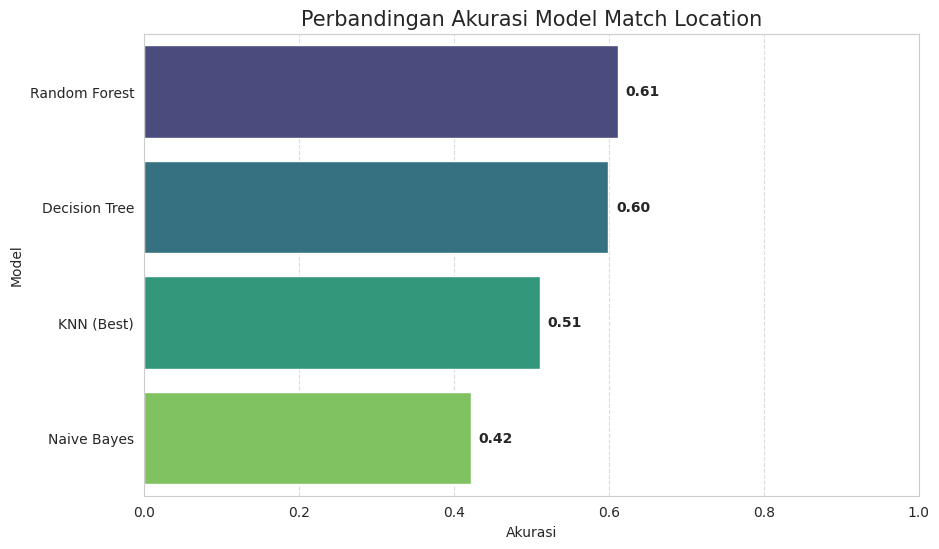

In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Mengumpulkan akurasi dari setiap model
comparison_data = {
    'Model': ['KNN (Best)', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_best_knn, accuracy_nb, accuracy_dt, accuracy_rf]
}

df_comparison = pd.DataFrame(comparison_data)

# Menampilkan tabel perbandingan
print("=== Tabel Perbandingan Akurasi ===")
display(df_comparison.sort_values(by='Accuracy', ascending=False))

# Visualisasi perbandingan akurasi
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_comparison.sort_values(by='Accuracy', ascending=False), palette='viridis', hue='Model', legend=False)
plt.xlim(0, 1)  # Akurasi maksimal adalah 1.0
plt.title('Perbandingan Akurasi Model Match Location', fontsize=15)
plt.xlabel('Akurasi')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Menambahkan teks nilai pada batang
for index, value in enumerate(df_comparison.sort_values(by='Accuracy', ascending=False)['Accuracy']):
    plt.text(value + 0.01, index, f'{value:.2f}', va='center', fontweight='bold')

plt.show()

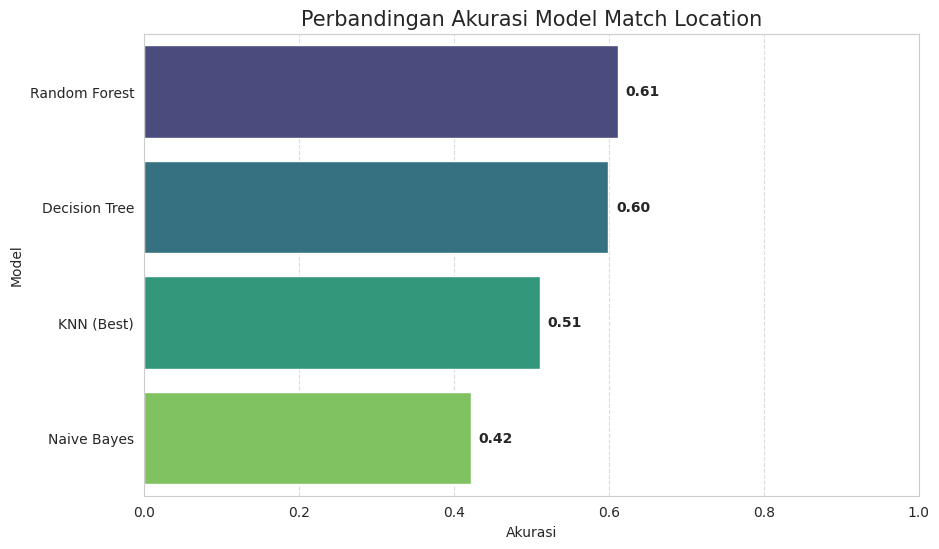

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mengumpulkan akurasi dari setiap model yang sudah dihitung sebelumnya
# Memastikan variabel akurasi tersedia
comparison_data = {
    'Model': ['KNN (Best)', 'Naive Bayes', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_best_knn, accuracy_nb, accuracy_dt, accuracy_rf]
}

df_comparison = pd.DataFrame(comparison_data)

# Visualisasi perbandingan akurasi
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_comparison.sort_values(by='Accuracy', ascending=False), palette='viridis', hue='Model', legend=False)
plt.xlim(0, 1)  # Akurasi maksimal adalah 1.0
plt.title('Perbandingan Akurasi Model Match Location', fontsize=15)
plt.xlabel('Akurasi')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Menambahkan teks nilai pada batang
for index, value in enumerate(df_comparison.sort_values(by='Accuracy', ascending=False)['Accuracy']):
    plt.text(value + 0.01, index, f'{value:.2f}', va='center', fontweight='bold')

plt.show()

### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model Decision Tree dengan GridSearchCV

In [149]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. Parameter grid untuk Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 2. GridSearch
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1_macro', n_jobs=-1)
dt_grid.fit(X_train, y_train)

# 3. Simpan ke Excel
results_dt = pd.DataFrame(dt_grid.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_dt.sort_values(by='rank_test_score').to_excel('hasil_gridsearch_decisiontree.xlsx', index=False)

print("Hasil Decision Tree disimpan ke 'hasil_gridsearch_decisiontree.xlsx'")
print("Best Params:", dt_grid.best_params_)

Hasil Decision Tree disimpan ke 'hasil_gridsearch_decisiontree.xlsx'
Best Params: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 5}


### Contoh penggunaan Model Random Forest dengan GridSearchCV

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Parameter grid untuk Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

# 2. GridSearch
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1_macro', n_jobs=-1)
rf_grid.fit(X_train, y_train)

# 3. Simpan ke Excel
results_rf = pd.DataFrame(rf_grid.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_rf.sort_values(by='rank_test_score').to_excel('hasil_gridsearch_randomforest.xlsx', index=False)

print("Hasil Random Forest disimpan ke 'hasil_gridsearch_randomforest.xlsx'")
print("Best Params:", rf_grid.best_params_)

### Contoh penggunaan Model Naive Bayes dengan GridSearchCV

In [160]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# 1. Parameter grid untuk KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 2. GridSearch
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1_macro', n_jobs=-1)
knn_grid.fit(X_train, y_train)

# 3. Simpan ke Excel
results_knn = pd.DataFrame(knn_grid.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_knn.sort_values(by='rank_test_score').to_excel('hasil_gridsearch_knn_v2.xlsx', index=False)

print("Hasil KNN GridSearch disimpan ke 'hasil_gridsearch_knn_v2.xlsx'")
print("Best Params:", knn_grid.best_params_)

Hasil KNN GridSearch disimpan ke 'hasil_gridsearch_knn_v2.xlsx'
Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


### Contoh penggunaan Model KNN dengan GridSearchCV

In [158]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro', zero_division=0),
    'f1': make_scorer(f1_score, average='macro', zero_division=0)
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print('\n=== Hasil Evaluasi Training (Cross-Validation) ===')
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.549615   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.547813   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.544144   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.544144   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.536937   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.536937   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.533219   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.533251   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.513382   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.513382   
8   {'metric': 'manhattan', 'n_neighbors

In [153]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel('hasil_gridsearch_knn.xlsx', index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [154]:
best_model = grid_search.best_estimator_
print('\n=== Parameter Terbaik ===')
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [155]:
y_pred = best_model.predict(X_test)
print('\n=== Evaluasi di Test Set ===')
print(f'Akurasi:  {accuracy_score(y_test, y_pred):.2f}')
print(f'Presisi:  {precision_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print(f'Recall:   {recall_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print(f'F1-Score: {f1_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.51
Presisi:  0.48
Recall:   0.48
F1-Score: 0.48

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.33      0.36        96
           1       0.58      0.63      0.61       141

    accuracy                           0.51       237
   macro avg       0.48      0.48      0.48       237
weighted avg       0.50      0.51      0.50       237

Confusion Matrix:
[[32 64]
 [52 89]]


In [156]:
import numpy as np

# Data gol baru (dalam urutan sama seperti fitur model)
new_data_1 = X_test.iloc[[0]]

# Prediksi apakah gol ini dicetak di kandang atau tandang
prediction = best_model.predict(new_data_1)

print('Prediksi (0 = Tandang, 1 = Kandang):', prediction[0])

Prediksi (0 = Tandang, 1 = Kandang): 0


# **Perbandingan Akhir Model (Optimized Results)**

Di bagian ini, kita membandingkan performa terbaik dari setiap model yang telah dioptimasi menggunakan GridSearchCV.

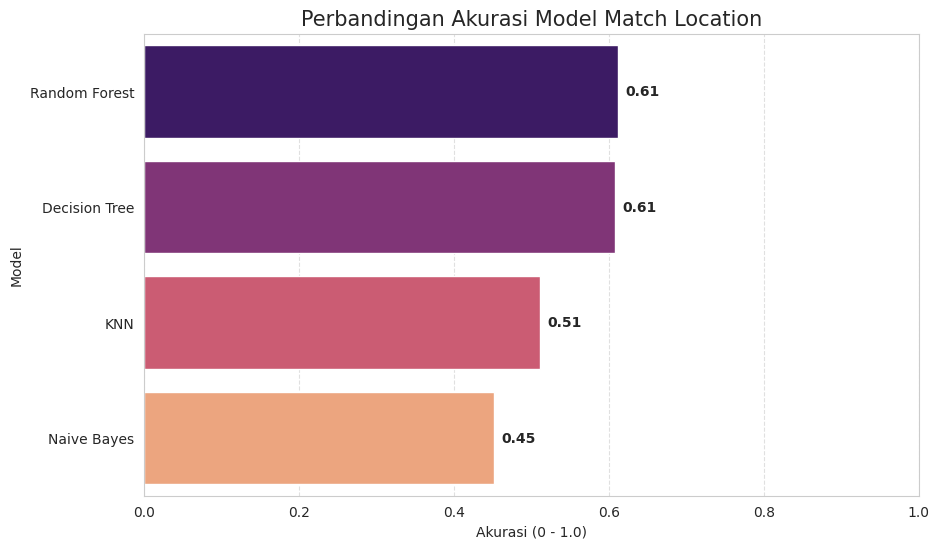

,Model,Accuracy
2,Random Forest,0.611814
1,Decision Tree,0.607595
0,KNN,0.510549
3,Naive Bayes,0.451477


In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Memastikan model terbaik diambil dari variabel yang sudah ada
# Jika GridSearchCV belum dijalankan, kita gunakan model dasar yang sudah dilatih
models_comparison = {}

try:
    models_comparison['KNN'] = knn_grid.best_estimator_
except:
    models_comparison['KNN'] = best_model

try:
    models_comparison['Decision Tree'] = dt_grid.best_estimator_
except:
    models_comparison['Decision Tree'] = dt

try:
    models_comparison['Random Forest'] = rf_grid.best_estimator_
except:
    models_comparison['Random Forest'] = rf

try:
    models_comparison['Naive Bayes'] = nb_grid.best_estimator_
except:
    models_comparison['Naive Bayes'] = nb

# Menghitung akurasi pada data uji
final_accuracies = {}
for name, model in models_comparison.items():
    y_pred_final = model.predict(X_test)
    final_accuracies[name] = accuracy_score(y_test, y_pred_final)

# Membuat DataFrame untuk visualisasi
df_final_comp = pd.DataFrame(list(final_accuracies.items()), columns=['Model', 'Accuracy'])
df_final_comp = df_final_comp.sort_values(by='Accuracy', ascending=False)

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_final_comp, palette='magma', hue='Model', legend=False)
plt.xlim(0, 1)
plt.title('Perbandingan Akurasi Model Match Location', fontsize=15)
plt.xlabel('Akurasi (0 - 1.0)')
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Menambahkan label nilai
for index, value in enumerate(df_final_comp['Accuracy']):
    plt.text(value + 0.01, index, f'{value:.2f}', va='center', fontweight='bold')

plt.show()

display(df_final_comp)

In [163]:
# Menyimpan hasil perbandingan ke file CSV
df_final_comp.to_csv('perbandingan_akurasi_model.csv', index=False)
print("Hasil perbandingan model telah disimpan ke 'perbandingan_akurasi_model.csv'")

Hasil perbandingan model telah disimpan ke 'perbandingan_akurasi_model.csv'
